# 03, P-V cut examples

Per `plan.md` §11 step 3. Take 10 known B11 holes and 10 random
sightlines from the same galaxy and render their p-v cut windows.
Visual sanity: the catalogued holes should show the characteristic
ellipse / cavity signature; the random sightlines should not. If they
do, either the cube/catalog alignment from notebook 02 is off, or the
B11 catalog is mis-keyed.

In [6]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from hishells.catalog import load_catalog
from hishells.cubes import load_cube, sigma_rms
from hishells.pvcut import extract_window_for_hole
from hishells.windows import NegSampleConfig, sample_negatives

In [7]:
REPO = Path('..').resolve()
DATA = REPO / 'Data' / 'THINGS'
GALAXY = 'NGC_2403'  # change me

cat = load_catalog(REPO / 'Data' / 'J_AJ_141_23')
cube = load_cube(DATA / f'{GALAXY}_NA_CUBE_THINGS.FITS')
sigma = sigma_rms(cube)
print(f'{GALAXY}: shape={cube.shape}, beam={cube.beam_bmaj_arcsec:.1f}", sigma_rms={sigma:.4g} Jy/beam')

NGC_2403: shape=(61, 2048, 2048), beam=8.8", sigma_rms=0.0003907 Jy/beam


In [8]:
# Pick 10 "textbook ellipse" holes: type-3 (two-sided expansion) so
# both walls of the p-v ellipse exist; axial_ratio ~ 1 so the
# projection is an actual ellipse and not a slit; Vexp > 5 km/s so
# the ellipse opens far enough to be visible across a few channels.
# This is the cleanest slice of B11 to eyeball pvcut.py against.
# Falls back to the prior "top by diameter" selector if too few rows
# pass, so the notebook still renders on galaxies with sparse type-3.
mask = (
    (cat.holes['galaxy_id'] == GALAXY)
    & (cat.holes['hole_type'] == 3)
    & (cat.holes['axial_ratio'].between(0.85, 1.0))
    & (cat.holes['vexp_kms'] > 5)
)
holes = (
    cat.holes[mask]
    .sort_values('diameter_pc', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
if len(holes) < 10:
    print(f'only {len(holes)} round type-3 holes in {GALAXY}; falling back to top type-{{2,3}} by diameter')
    holes = (
        cat.holes[(cat.holes['galaxy_id'] == GALAXY) & (cat.holes['hole_type'].isin([2, 3]))]
        .sort_values('diameter_pc', ascending=False)
        .head(10)
        .reset_index(drop=True)
    )
else:
    print(f'showing {len(holes)} round type-3 holes in {GALAXY} (axial_ratio in [0.85, 1.0], Vexp > 5 km/s)')

showing 10 round type-3 holes in NGC_2403 (axial_ratio in [0.85, 1.0], Vexp > 5 km/s)


In [9]:
def show_window(ax, win, title, vmin=None, vmax=None):
    # Per-window percentile stretch: each panel scales to its own
    # brightness range so the dark cavity sits at the bottom of the
    # colormap and the bright wall at the top, both visible
    # simultaneously. A sigma_rms-based stretch saturates here because
    # the in-galaxy windows are well above the empty-channel noise.
    if vmin is None or vmax is None:
        vmin, vmax = np.percentile(win, [2, 99])
    ax.imshow(win, origin='lower', cmap='magma', vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])

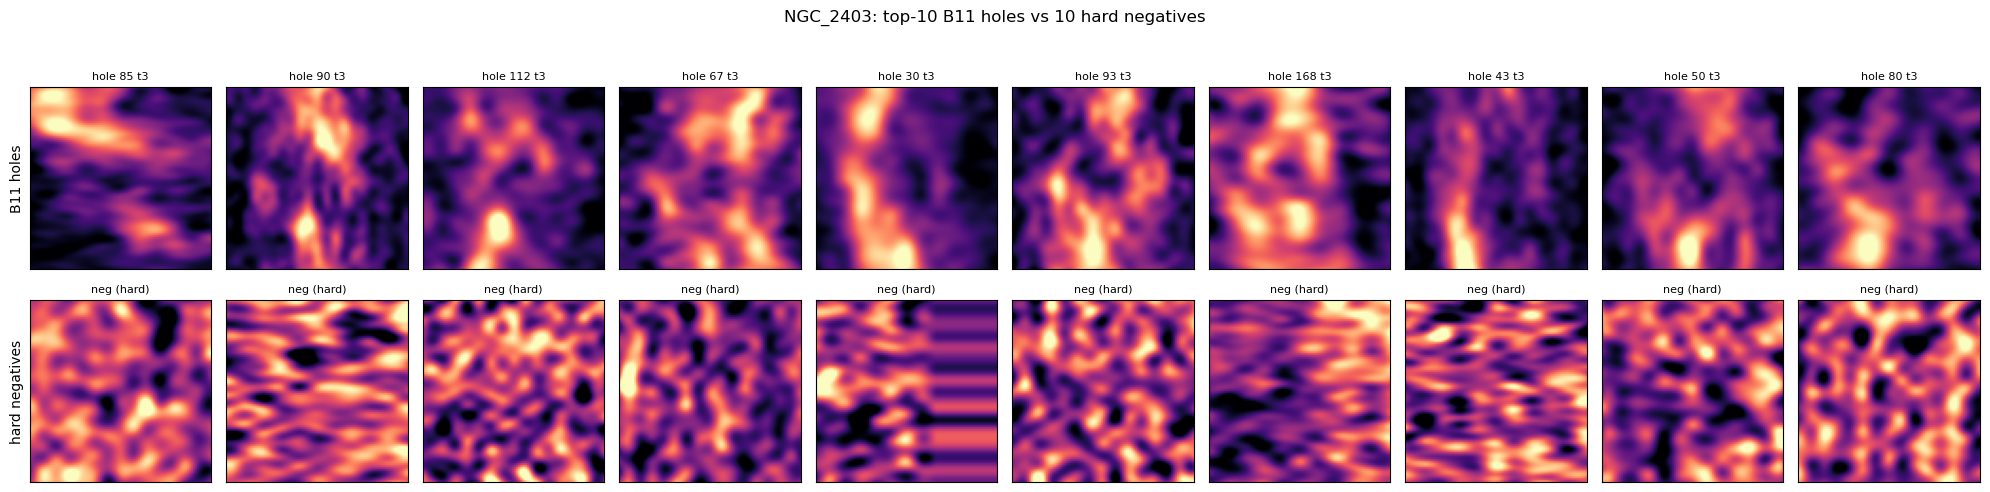

In [10]:
fig, axes = plt.subplots(2, 10, figsize=(20, 5))
for ax, (_, h) in zip(axes[0], holes.iterrows()):
    win = extract_window_for_hole(cube, h.to_dict(), window_pix=96)
    show_window(ax, win, f"hole {h.hole_idx} t{h.hole_type}")
axes[0, 0].set_ylabel('B11 holes', fontsize=10)

# Hard in-galaxy negatives -- the same sampler training uses, with
# hard_frac=1.0 so the bottom row is the hard discrimination case
# (matched window extents, offset by >= 2*diameter from any positive).
# The previous version drew uniformly over the cube footprint, so most
# negatives landed off-galaxy and the visual contrast with positives
# was much easier than the actual training task.
n_neg = 10
neg_cfg = NegSampleConfig(
    ratio=max(n_neg / max(len(holes), 1), 1.0),
    hard_frac=1.0,
    rng_seed=0,
)
negs = sample_negatives(cube, holes, neg_cfg).head(n_neg).reset_index(drop=True)
for ax, (_, n) in zip(axes[1], negs.iterrows()):
    win = extract_window_for_hole(cube, n.to_dict(), window_pix=96)
    show_window(ax, win, f"neg ({n.neg_kind})")
axes[1, 0].set_ylabel('hard negatives', fontsize=10)
fig.suptitle(f'{GALAXY}: top-10 B11 holes vs {len(negs)} hard negatives', y=1.02)
plt.tight_layout()

## Pass criterion

* **Top row (B11 holes):** most panels show a darker interior bordered
  by a brighter rim -- the p-v ellipse cavity signature. Per-window
  percentile stretch (see `show_window` above) ensures both the cavity
  and the wall are visible simultaneously regardless of the absolute
  emission level, which varies a lot across galaxies.
* **Bottom row (hard negatives):** in-galaxy patches drawn by
  `hishells.windows.sample_negatives` with `hard_frac=1.0`. They show
  emission with no consistent ellipse / cavity at the centre. This is
  the actual training-time discrimination task -- expect it to look
  visually harder than off-galaxy noise.

If the two rows look indistinguishable to the eye, the model still has
a learnable signal at training time (§6.1 success criteria allow for a
hard task), but the cavity feature is the diagnostic the CNN is
supposed to key on. If positives also fail to show cavities, suspect
`pvcut.py` (PA rotation in `_sightline_pix`, or the velocity-axis flip
branch around lines 177--178) and run

```bash
pytest tests/test_pvcut.py -k pv_ellipse
```

to localize. That test asserts the synthetic-shell window has the
right velocity-axis cavity shape; if it passes, the issue is data, not
code, and the next step is `04_window_inspection.ipynb`'s diagnostics.